# Louisiana 2026 Primary and Runoff Precinct Conversion

This notebook combines Louisiana's 2026 primary workbook and primary
runoff CSV exports into a complete reporting-unit CSV and an allocated
precinct shapefile. It retains federal and state-level contests and
statewide constitutional amendments while excluding parish and municipal
contests. The spatial output joins official precinct boundaries, combines
split reporting rows, and allocates Early Voting and Provisional Votes.

**Primary source:** `LA_raw_data/Election+Results+(05-16-2026).xlsx`

**Runoff sources:** `LA_raw_data/ByPrecinct_*.csv`

**Outputs:**

- `la_2026_primary_prec.csv`
- `la_2026_primary_prec_shp.zip`

## Setup

Run this notebook from the project folder containing `LA_raw_data`.
The Excel reader uses Pandas with the `python-calamine` engine.

In [1]:
import re
from pathlib import Path

import pandas as pd


ROOT = Path.cwd()
if not (ROOT / "LA_raw_data").exists():
    raise FileNotFoundError("Run this notebook from the project folder that contains LA_raw_data.")
RAW_DIR = ROOT / "LA_raw_data"
WORKBOOK_PATH = RAW_DIR / "Election+Results+(05-16-2026).xlsx"
OUTPUT_PATH = ROOT / "la_2026_primary_prec.csv"
EXPECTED_ROWS = 3850
EXPECTED_PRIMARY_CONTESTS = 12
EXPECTED_PRIMARY_COLUMNS = 31
EXPECTED_VOTE_COLUMNS = 39
EXPECTED_RUNOFF_COLUMNS = 8
RUNOFF_CONTESTS = {
    "ByPrecinct_70139.csv": "BESE -- District 1 - Republican Party",
    "ByPrecinct_70154.csv": "PSC -- District 1 - Republican Party",
    "ByPrecinct_70156.csv": "U. S. Senator -- Democratic Party",
    "ByPrecinct_70157.csv": "U. S. Senator -- Republican Party",
}
INCLUDED_CONTEST_PREFIXES = ("U. S. Senator", "PSC", "Associate Justice", "BESE", "CA No.")
DISTRICT_RACE_TOKENS = {"PSC": "PSC", "Associate Justice": "JUS", "BESE": "BES"}
NAME_SUFFIXES = {"I", "II", "III", "IV", "JR", "JR.", "SR", "SR."}
PARISH_FIPS = {
    "Acadia": "001",
    "Allen": "003",
    "Ascension": "005",
    "Assumption": "007",
    "Avoyelles": "009",
    "Beauregard": "011",
    "Bienville": "013",
    "Bossier": "015",
    "Caddo": "017",
    "Calcasieu": "019",
    "Caldwell": "021",
    "Cameron": "023",
    "Catahoula": "025",
    "Claiborne": "027",
    "Concordia": "029",
    "De Soto": "031",
    "East Baton Rouge": "033",
    "East Carroll": "035",
    "East Feliciana": "037",
    "Evangeline": "039",
    "Franklin": "041",
    "Grant": "043",
    "Iberia": "045",
    "Iberville": "047",
    "Jackson": "049",
    "Jefferson": "051",
    "Jefferson Davis": "053",
    "Lafayette": "055",
    "Lafourche": "057",
    "Lasalle": "059",
    "Lincoln": "061",
    "Livingston": "063",
    "Madison": "065",
    "Morehouse": "067",
    "Natchitoches": "069",
    "Orleans": "071",
    "Ouachita": "073",
    "Plaquemines": "075",
    "Pointe Coupee": "077",
    "Rapides": "079",
    "Red River": "081",
    "Richland": "083",
    "Sabine": "085",
    "St. Bernard": "087",
    "St. Charles": "089",
    "St. Helena": "091",
    "St. James": "093",
    "St. John The Baptist": "095",
    "St. Landry": "097",
    "St. Martin": "099",
    "St. Mary": "101",
    "St. Tammany": "103",
    "Tangipahoa": "105",
    "Tensas": "107",
    "Terrebonne": "109",
    "Union": "111",
    "Vermilion": "113",
    "Vernon": "115",
    "Washington": "117",
    "Webster": "119",
    "West Baton Rouge": "121",
    "West Carroll": "123",
    "West Feliciana": "125",
    "Winn": "127",
}

## Input

In [2]:
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 120)

input_paths = [WORKBOOK_PATH, *(RAW_DIR / filename for filename in RUNOFF_CONTESTS)]
for path in input_paths:
    assert path.exists(), f"Missing input: {path}"
    print(f"{path.name}: {path.stat().st_size:,} bytes")

Election+Results+(05-16-2026).xlsx: 349,281 bytes
ByPrecinct_70139.csv: 29,458 bytes
ByPrecinct_70154.csv: 45,698 bytes
ByPrecinct_70156.csv: 267,534 bytes
ByPrecinct_70157.csv: 269,251 bytes


## Helper Functions

In [3]:
def clean(value: object) -> str:
    """Return a stripped single-space label for workbook keys."""
    if pd.isna(value):
        return ""
    return " ".join(str(value).split())


def votes(series: pd.Series) -> pd.Series:
    """Parse workbook vote cells."""
    text = series.astype("string").str.replace(",", "", regex=False)
    return pd.to_numeric(text, errors="coerce").fillna(0).astype(int)


def sheets() -> dict[str, pd.DataFrame]:
    """Read workbook sheets through Pandas."""
    raw = pd.read_excel(WORKBOOK_PATH, sheet_name=None, header=None, dtype=object, engine="calamine")
    return {name: sheet.dropna(axis=1, how="all") for name, sheet in raw.items()}


def candidate_options(header: pd.Series) -> pd.DataFrame:
    """Return nonblank candidate/option labels with their source columns."""
    return (
        header.iloc[1:]
        .loc[lambda labels: labels.ne("")]
        .rename_axis("source_col")
        .rename("candidate_option")
        .reset_index()
    )


def contest_start_indices(clean_df: pd.DataFrame) -> list[int]:
    """Return row numbers where workbook contest blocks start."""
    title = clean_df.iloc[:, 0]
    blocked = title.isin({"", "Louisiana Secretary of State", "Election Results", "Total Votes"})
    blocked = blocked | title.str.startswith("Election Date:")
    next_first_blank = title.shift(-1).eq("")
    next_has_options = clean_df.iloc[:, 1:].ne("").any(axis=1).shift(-1, fill_value=False)
    return clean_df.index[~blocked & next_first_blank & next_has_options].tolist()


def included_contest(title: str) -> bool:
    """Return whether a workbook contest belongs in the statewide file."""
    return title.startswith(INCLUDED_CONTEST_PREFIXES)


def contest_token(title: str) -> str:
    """Return the compact contest portion of a vote column name.

    U.S. Senate returns `26USS`, constitutional amendments return `26A1`
    through `26A5`, and district races return `PSC05`, `JUS01`, or `BES01`.
    District titles omit the year so the complete vote column stays within the
    shapefile limit of 10 characters. For the retained district-title formats,
    the first integer in the title is the district number.
    """
    if title.startswith("U. S. Senator"):
        return "26USS"
    if title.startswith("CA No."):
        amendment = re.match(r"CA No\. (\d+)", title)
        assert amendment
        return f"26A{amendment.group(1)}"

    for prefix, token in DISTRICT_RACE_TOKENS.items():
        if title.startswith(prefix):
            district = re.search(r"\d+", title)
            assert district
            return f"{token}{int(district.group()):02d}"
    raise AssertionError(f"No contest token for: {title!r}")


def option_token(candidate: str) -> str:
    """Return the candidate/option token used in vote columns.

    `YES` and `NO` stay literal. Candidate names use the first three letters of
    the last meaningful name part, skipping suffixes like `Jr.` and `III`.
    """
    label = re.sub(r"\s*\([^)]+\)\s*$", "", candidate).replace("'", "")
    words = re.findall(r"[A-Za-z0-9]+", label.upper())
    if not words:
        return "X"
    if words[0] in {"YES", "NO"}:
        return words[0]

    last = words[-1]
    if last in NAME_SUFFIXES and len(words) > 1:
        last = words[-2]
    return last[:3]


def column_codes(contest_title: str, candidates: pd.Series, election_type: str = "P") -> list[str]:
    """Return shapefile-safe vote columns for one retained contest.

    The output is `{election_type}{contest_token}{option_token}`. Candidate
    options add the party initial and first three letters of the likely surname;
    `YES` and `NO` remain literal. Examples include `P26USSDCRO`,
    `PPSC05DGRE`, `PJUS01RBUR`, `PBES01RCAO`, and `P26A1YES`.
    """
    party_initials = candidates.str.extract(r"\(([^)]+)\)\s*$", expand=False).str[:1].fillna("")
    options = [f"{party}{option_token(candidate)}" for party, candidate in zip(party_initials, candidates)]
    codes = [f"{election_type}{contest_token(contest_title)}{option}" for option in options]
    assert len(codes) == len(set(codes)), f"Duplicate vote columns for: {contest_title!r}"
    assert all(len(code) <= 10 for code in codes), f"Vote column exceeds 10 characters: {contest_title!r}"
    return codes


def parse_workbook() -> tuple[
    pd.DataFrame,
    list[str],
    dict[str, dict[str, str]],
    dict[str, set[tuple[str, str]]],
]:
    """Parse retained primary votes and lookup data for the runoff contests."""
    vote_rows: list[pd.DataFrame] = []
    vote_columns: list[str] = []
    primary_codes: dict[str, dict[str, str]] = {}
    primary_precincts: dict[str, set[tuple[str, str]]] = {}
    contest_count = 0

    for sheet_name, df in sheets().items():
        if sheet_name == "Multi-Parish(Parish)":
            continue

        clean_df = df.map(clean)
        starts = contest_start_indices(clean_df)
        for position, idx in enumerate(starts):
            title = clean_df.iat[idx, 0]
            if not included_contest(title):
                continue

            end = starts[position + 1] if position + 1 < len(starts) else len(df)
            contest_count += 1
            options = candidate_options(clean_df.iloc[idx + 1])
            totals = df.iloc[idx + 2]
            assert clean_df.iat[idx + 2, 0] == "Total Votes", f"Expected Total Votes row: {sheet_name!r}, row {idx + 3}"
            contest_codes = column_codes(title, options["candidate_option"])
            contest_options = options.assign(column_code=contest_codes)
            rows = contest_precinct_rows(df, clean_df, idx + 3, end, sheet_name, contest_options)
            total_votes = votes(totals.reindex(contest_options["source_col"]))
            detail_votes = rows.groupby("column_code", sort=False)["votes"].sum().reindex(contest_codes)
            assert detail_votes.eq(total_votes.to_numpy()).all(), f"Total Votes mismatch: {title!r}"

            if title in RUNOFF_CONTESTS.values():
                assert title not in primary_codes, f"Duplicate runoff contest in workbook: {title!r}"
                primary_codes[title] = dict(zip(options["candidate_option"], contest_codes))
                primary_precincts[title] = set(
                    rows[["Parish", "Precinct"]].itertuples(index=False, name=None)
                )

            vote_columns.extend(contest_codes)
            vote_rows.append(rows)

    assert contest_count == EXPECTED_PRIMARY_CONTESTS
    assert set(primary_codes) == set(RUNOFF_CONTESTS.values())
    return pd.concat(vote_rows, ignore_index=True), vote_columns, primary_codes, primary_precincts


def contest_precinct_rows(
    df: pd.DataFrame,
    clean_df: pd.DataFrame,
    start: int,
    end: int,
    sheet_name: str,
    contest_options: pd.DataFrame,
) -> pd.DataFrame:
    """Melt one contest block into long-form precinct/candidate vote rows."""
    block = clean_df.iloc[start:end]
    labels = block.iloc[:, 0]

    if sheet_name == "Multi-Parish(Precinct)":
        parish_heading = labels.ne("") & block.iloc[:, 1:].eq("").all(axis=1)
        unknown = labels.loc[parish_heading & ~labels.isin(PARISH_FIPS)]
        assert unknown.empty, f"Unknown parish heading in Multi-Parish(Precinct): {unknown.iloc[0]!r}"
        parish_values = labels.where(parish_heading).ffill()
        precinct_mask = labels.ne("") & ~parish_heading & parish_values.ne("")
    else:
        parish_values = pd.Series(sheet_name, index=labels.index)
        precinct_mask = labels.ne("")

    vote_wide = df.loc[labels.index[precinct_mask], contest_options["source_col"]].copy()
    vote_wide.columns = contest_options["column_code"]
    vote_wide.insert(0, "Parish", parish_values.loc[precinct_mask].to_numpy())
    vote_wide.insert(1, "Precinct", labels.loc[precinct_mask].to_numpy())

    return (
        vote_wide.melt(id_vars=["Parish", "Precinct"], var_name="column_code", value_name="votes")
        .assign(votes=lambda frame: votes(frame["votes"]))
    )[["Parish", "Precinct", "column_code", "votes"]]


def runoff_precincts(df: pd.DataFrame) -> pd.Series:
    """Return `Ward Precinct`, or the populated field for nonstandard reporting units."""
    return df[["Ward", "Precinct"]].agg(" ".join, axis=1).str.strip()


def parse_runoffs(
    primary_codes: dict[str, dict[str, str]],
    primary_precincts: dict[str, set[tuple[str, str]]],
) -> tuple[pd.DataFrame, list[str]]:
    """Parse the four runoff CSVs into long vote rows with paired `R` codes."""
    vote_rows: list[pd.DataFrame] = []
    vote_columns: list[str] = []
    id_columns = ["Office", "Parish", "Ward", "Precinct"]

    for filename, title in RUNOFF_CONTESTS.items():
        df = pd.read_csv(RAW_DIR / filename, dtype=str, keep_default_na=False)
        assert df["Office"].eq(title).all(), f"Unexpected office in {filename!r}"

        candidate_columns = df.columns.drop(id_columns).tolist()
        assert set(candidate_columns) <= primary_codes[title].keys(), f"Candidate mismatch in {filename!r}"
        candidate_codes = {
            candidate: f"R{primary_codes[title][candidate][1:]}"
            for candidate in candidate_columns
        }

        runoff_wide = (
            df.assign(Precinct=runoff_precincts(df))
            [["Parish", "Precinct", *candidate_columns]]
            .rename(columns=candidate_codes)
        )
        runoff_keys = set(runoff_wide[["Parish", "Precinct"]].itertuples(index=False, name=None))
        assert runoff_keys == primary_precincts[title], f"Reporting-unit mismatch in {filename!r}"
        assert not runoff_wide.duplicated(["Parish", "Precinct"]).any()

        contest_codes = list(candidate_codes.values())
        rows = (
            runoff_wide.melt(
                id_vars=["Parish", "Precinct"],
                var_name="column_code",
                value_name="votes",
            )
            .assign(votes=lambda frame: votes(frame["votes"]))
        )
        source_totals = df[candidate_columns].apply(votes).sum().rename(index=candidate_codes)
        parsed_totals = rows.groupby("column_code", sort=False)["votes"].sum().reindex(contest_codes)
        assert parsed_totals.eq(source_totals.reindex(contest_codes)).all()

        vote_columns.extend(contest_codes)
        vote_rows.append(rows)

    return pd.concat(vote_rows, ignore_index=True), vote_columns


def build_output() -> pd.DataFrame:
    """Build the final precinct CSV table."""
    primary_rows, primary_columns, primary_codes, primary_precincts = parse_workbook()
    runoff_rows, runoff_columns = parse_runoffs(primary_codes, primary_precincts)

    primary = (
        primary_rows.pivot(index=["Parish", "Precinct"], columns="column_code", values="votes")
        .reset_index()
        .rename_axis(columns=None)
    )
    runoff = (
        runoff_rows.pivot(index=["Parish", "Precinct"], columns="column_code", values="votes")
        .reset_index()
        .rename_axis(columns=None)
    )
    out = primary.merge(runoff, on=["Parish", "Precinct"], how="left", validate="one_to_one")

    runoff_by_primary = {f"P{column[1:]}": column for column in runoff_columns}
    vote_columns = sorted([*primary_columns, *runoff_columns])

    out["COUNTYFP"] = out["Parish"].map(PARISH_FIPS)
    out["UNIQUE_ID"] = out["Parish"] + "-:-" + out["Precinct"]
    out[vote_columns] = out[vote_columns].fillna(0).astype(int)
    out = out[["UNIQUE_ID", "COUNTYFP", "Parish", "Precinct", *vote_columns]].sort_values(
        ["COUNTYFP", "Parish", "Precinct"], kind="stable"
    )

    assert out.shape == (EXPECTED_ROWS, EXPECTED_VOTE_COLUMNS + 4)
    assert len(primary_columns) == EXPECTED_PRIMARY_COLUMNS
    assert len(vote_columns) == EXPECTED_VOTE_COLUMNS
    assert len(runoff_columns) == EXPECTED_RUNOFF_COLUMNS
    assert set(runoff_by_primary) <= set(primary_columns)
    assert len(vote_columns) == len(set(vote_columns))
    assert all(len(column) <= 10 for column in out.columns)
    assert out["UNIQUE_ID"].is_unique
    assert out[["UNIQUE_ID", "COUNTYFP", "Parish", "Precinct"]].notna().all().all()
    assert out[vote_columns].ge(0).all().all()
    return out

## Build Precinct CSV

In [4]:
output = build_output()
print(f"output shape: {output.shape[0]:,} rows x {output.shape[1]:,} columns")
display(output.iloc[:, :12].head())

output shape: 3,850 rows x 43 columns


,UNIQUE_ID,COUNTYFP,Parish,Precinct,P26A1NO,P26A1YES,P26A2NO,P26A2YES,P26A3NO,P26A3YES,P26A4NO,P26A4YES
0,Acadia-:-01 01,001,Acadia,01 01,148,59,123,83,110,97,101,103
1,Acadia-:-01 02,001,Acadia,01 02,116,43,81,77,85,75,79,81
2,Acadia-:-01 03,001,Acadia,01 03,118,49,99,57,82,83,84,83
3,Acadia-:-01 04,001,Acadia,01 04,146,55,107,92,95,106,93,105
4,Acadia-:-01 05,001,Acadia,01 05,37,9,33,14,36,11,32,14


## Validation

In [5]:
def review_output(output: pd.DataFrame) -> pd.DataFrame:
    """Summarize final CSV checks."""
    vote_columns = output.columns[4:]
    primary_columns = vote_columns[vote_columns.str.startswith("P")]
    runoff_columns = vote_columns[vote_columns.str.startswith("R")]
    missing_primary_pairs = [
        column for column in runoff_columns
        if f"P{column[1:]}" not in vote_columns
    ]
    return pd.DataFrame(
        [
            (
                "row_count",
                "The output contains one row for each of the 3,850 parish and precinct reporting units found in the statewide primary results.",
                len(output) == EXPECTED_ROWS,
                len(output),
            ),
            (
                "primary_column_count",
                "The output contains all 31 retained primary candidate and ballot-option vote columns.",
                len(primary_columns) == EXPECTED_PRIMARY_COLUMNS,
                len(primary_columns),
            ),
            (
                "vote_column_count",
                "The output contains 39 vote columns in total: 31 primary columns and 8 runoff columns.",
                len(vote_columns) == EXPECTED_VOTE_COLUMNS,
                len(vote_columns),
            ),
            (
                "runoff_column_count",
                "The output contains all 8 candidate vote columns from the four primary-runoff CSV files.",
                len(runoff_columns) == EXPECTED_RUNOFF_COLUMNS,
                len(runoff_columns),
            ),
            (
                "paired_runoff_columns",
                "Every runoff candidate column has a corresponding column for that candidate in the primary results. Detail is the number of missing primary columns.",
                not missing_primary_pairs,
                len(missing_primary_pairs),
            ),
            (
                "sorted_vote_columns",
                "Vote columns are alphabetically sorted, placing all P primary columns before all R runoff columns.",
                vote_columns.tolist() == sorted(vote_columns),
                "alphabetical",
            ),
            (
                "field_name_length",
                "Every output field name is at most 10 characters, making the schema compatible with shapefiles. Detail is the longest field name.",
                output.columns.str.len().max() <= 10,
                int(output.columns.str.len().max()),
            ),
            (
                "unique_ids",
                "Each reporting unit has a distinct UNIQUE_ID. Detail is the number of duplicate IDs.",
                output["UNIQUE_ID"].is_unique,
                int(output["UNIQUE_ID"].duplicated().sum()),
            ),
            (
                "countyfp_present",
                "Every reporting unit has a three-digit Louisiana parish FIPS code for geographic joins. Detail is the number of missing codes.",
                output["COUNTYFP"].notna().all(),
                int(output["COUNTYFP"].isna().sum()),
            ),
            (
                "nonnegative_votes",
                "No candidate or ballot-option vote count is negative. Detail is the number of negative values.",
                output[vote_columns].ge(0).all().all(),
                int(output[vote_columns].lt(0).sum().sum()),
            ),
        ],
        columns=["check", "description", "passed", "detail"],
    )

summary = review_output(output)
display(summary)

if not summary["passed"].all():
    raise AssertionError("One or more required validation checks failed.")

,check,description,passed,detail
0,row_count,"The output contains one row for each of the 3,850 parish and precinct reporting units found in the statewide primary results.",True,3850
1,primary_column_count,The output contains all 31 retained primary candidate and ballot-option vote columns.,True,31
2,vote_column_count,The output contains 39 vote columns in total: 31 primary columns and 8 runoff columns.,True,39
3,runoff_column_count,The output contains all 8 candidate vote columns from the four primary-runoff CSV files.,True,8
4,paired_runoff_columns,Every runoff candidate column has a corresponding column for that candidate in the primary results. Detail is the number of missing primary columns.,True,0
5,sorted_vote_columns,"Vote columns are alphabetically sorted, placing all P primary columns before all R runoff columns.",True,alphabetical
6,field_name_length,"Every output field name is at most 10 characters, making the schema compatible with shapefiles. Detail is the longest field name.",True,10
7,unique_ids,Each reporting unit has a distinct UNIQUE_ID. Detail is the number of duplicate IDs.,True,0
8,countyfp_present,Every reporting unit has a three-digit Louisiana parish FIPS code for geographic joins. Detail is the number of missing codes.,True,0
9,nonnegative_votes,No candidate or ballot-option vote count is negative. Detail is the number of negative values.,True,0


## Export

In [6]:
output.to_csv(OUTPUT_PATH, index=False)

print(f"wrote {OUTPUT_PATH.name}")

wrote la_2026_primary_prec.csv


## Precinct Shapefile

The official January 27, 2026 precinct boundaries are joined to the
physical reporting units below. Early Voting and Provisional Votes remain
separate in the CSV; in the spatial file, they are allocated within each
parish according to each candidate or ballot option's physical-precinct
vote shares. The final figure shows all 39 vote columns, using blue for
primary fields and orange for runoff fields.

The official source contains seven self-intersecting geometries. They are
reported in validation and retained without modification. Five areas not
assigned to a voting district are also retained to preserve the source
boundary coverage; they have zero vote values.

In [7]:
import re
import shutil
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_PATH = ROOT / "la_2026_primary_prec.csv"
SHAPEFILE_DIR = ROOT / "la_2026_primary_prec_shp"
SHAPEFILE_PATH = SHAPEFILE_DIR / "la_2026_primary_prec_shp.shp"
SHAPEFILE_ZIP = ROOT / "la_2026_primary_prec_shp.zip"
SHAPEFILE_PAGE_URL = "https://redist.legis.la.gov/default_ShapeFiles2020"
SHAPEFILE_URL = (
    "https://redist.legis.la.gov/2026_Files/Shapefiles/"
    "2026%20Precinct%20Shapefiles%20%2801-27-2026%29.zip"
)
SPECIAL_PRECINCTS = {"Early Voting", "Provisional Votes"}
REPORTING_SPLIT_PARISHES = {
    "Ascension",
    "Assumption",
    "East Baton Rouge",
    "Lafourche",
    "Rapides",
    "St. Charles",
    "Terrebonne",
}
EXPECTED_PHYSICAL_ROWS = 3722
EXPECTED_SPECIAL_ROWS = 128
EXPECTED_SPATIAL_ROWS = 3574
EXPECTED_UNDEFINED_AREAS = 5
EXPECTED_INVALID_GEOMETRIES = 7

In [8]:
def canonical_label(value: str) -> str:
    """Return a tokenized precinct label with numeric zero padding removed.

    Hyphens between tokens keep labels such as `1-11` distinct from `11-1`.
    For example, `01-002A` becomes `1-2-A`, `G001` becomes `G-1`, and
    `7-KA` remains `7-KA`.
    """
    parts = re.findall(r"[A-Za-z]+|\d+", value)
    return "-".join(str(int(part)) if part.isdigit() else part.upper() for part in parts)


def result_shape_label(parish: str, precinct: str) -> tuple[str, str]:
    """Return the shapefile-style label and rule used for one election row."""
    ward, label = precinct.split(" ", 1)

    if parish == "Bossier":
        shape_label = re.sub(r" -[12]$", "", label)
        method = "bossier_split" if shape_label != label else "exact"
        return f"{ward} {shape_label}", method
    if parish == "Evangeline":
        return label, "evangeline_label"
    if parish == "Jefferson":
        prefixed = re.fullmatch(r"([A-Za-z]+)(\d+)([A-Za-z]*)", label)
        if prefixed:
            return f"{prefixed.group(2)}{prefixed.group(1)}{prefixed.group(3)}", "jefferson_prefix"
        return label, "exact"

    return (label if ward == "00" else f"{ward} {label}"), "exact"


def match_shape_key(
    countyfp: str,
    parish: str,
    precinct: str,
    shape_keys: set[str],
) -> tuple[str, str]:
    """Return the unique official shape key and matching rule for an election row.

    Exact and parish-specific labels are preferred. If that label is absent,
    a trailing alphabetic reporting split is removed only when the resulting
    key exists in the official shapefile.
    """
    label, method = result_shape_label(parish, precinct)
    key = f"{countyfp}:{canonical_label(label)}"
    if key in shape_keys:
        return key, method

    assert parish in REPORTING_SPLIT_PARISHES
    base_key = re.sub(r"-[A-Z]+$", "", key)
    assert base_key in shape_keys, f"No precinct geometry for {parish}-:-{precinct}"
    return base_key, "reporting_split"


def read_precinct_shapes() -> gpd.GeoDataFrame:
    """Download and read the official January 27, 2026 precinct shapefile."""
    with TemporaryDirectory() as temp_dir:
        zip_path = Path(temp_dir) / "la_2026_precincts.zip"
        urlretrieve(SHAPEFILE_URL, zip_path)
        return gpd.read_file(zip_path)


def prepare_shapes(shapes: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Return the 3,574 official VTD features, including undefined areas."""
    prepared = shapes[["COUNTY", "VTD", "GEOID20", "geometry"]].rename(
        columns={"COUNTY": "COUNTYFP", "VTD": "Precinct"}
    )
    prepared["SHAPE_KEY"] = (
        prepared["COUNTYFP"] + ":" + prepared["Precinct"].map(canonical_label)
    )
    assert len(prepared) == EXPECTED_SPATIAL_ROWS
    assert prepared["SHAPE_KEY"].is_unique
    return prepared


def build_crosswalk(physical: pd.DataFrame, shapes: gpd.GeoDataFrame) -> pd.DataFrame:
    """Map every physical election reporting row to one official precinct."""
    shape_keys = set(shapes["SHAPE_KEY"])
    matches = [
        match_shape_key(row.COUNTYFP, row.Parish, row.Precinct, shape_keys)
        for row in physical.itertuples(index=False)
    ]
    crosswalk = physical[["UNIQUE_ID", "COUNTYFP", "Parish", "Precinct"]].copy()
    crosswalk[["SHAPE_KEY", "match_method"]] = matches

    assert len(crosswalk) == EXPECTED_PHYSICAL_ROWS
    assert crosswalk["UNIQUE_ID"].is_unique
    assert set(crosswalk["SHAPE_KEY"]) == shape_keys
    return crosswalk


def allocate_special_votes(
    spatial: gpd.GeoDataFrame,
    special: pd.DataFrame,
    vote_columns: list[str],
) -> gpd.GeoDataFrame:
    """Allocate each parish's non-geographic votes to its precinct geometries.

    Each candidate or ballot option is allocated according to its existing
    precinct vote share. Fractional votes are rounded with the largest-remainder
    method so every parish and vote-column total is preserved exactly.
    """
    allocated = spatial.copy()
    special_totals = special.groupby("COUNTYFP")[vote_columns].sum()

    for countyfp, votes in special_totals.iterrows():
        parish_rows = allocated["COUNTYFP"].eq(countyfp) & allocated["Precinct"].ne("ZZZZZZ")
        precinct_votes = allocated.loc[parish_rows, vote_columns]
        denominators = precinct_votes.sum()
        assert denominators[votes.gt(0)].gt(0).all()

        exact = precinct_votes.div(denominators.where(denominators.ne(0))).mul(votes).fillna(0)
        additions = exact.astype(int)
        remaining = votes - additions.sum()
        assert remaining.ge(0).all()

        for column, count in remaining[remaining.gt(0)].items():
            remainders = exact[column] - additions[column]
            additions.loc[remainders.nlargest(count).index, column] += 1

        assert additions.sum().eq(votes).all()
        allocated.loc[parish_rows, vote_columns] = precinct_votes + additions

    return allocated


def build_spatial_results(results: pd.DataFrame) -> tuple[gpd.GeoDataFrame, pd.DataFrame]:
    """Join physical results to geometry and allocate non-geographic votes."""
    physical = results.loc[~results["Precinct"].isin(SPECIAL_PRECINCTS)]
    special = results.loc[results["Precinct"].isin(SPECIAL_PRECINCTS)]
    vote_columns = results.columns[4:].tolist()

    assert len(results) == EXPECTED_PHYSICAL_ROWS + EXPECTED_SPECIAL_ROWS
    assert len(physical) == EXPECTED_PHYSICAL_ROWS
    assert len(special) == EXPECTED_SPECIAL_ROWS

    shapes = prepare_shapes(read_precinct_shapes())
    precinct_shapes = shapes.loc[shapes["Precinct"].ne("ZZZZZZ")]
    crosswalk = build_crosswalk(physical, precinct_shapes)
    mapped = physical.merge(
        crosswalk[["UNIQUE_ID", "SHAPE_KEY"]],
        on="UNIQUE_ID",
        validate="one_to_one",
    )
    totals = mapped.groupby("SHAPE_KEY", as_index=False)[vote_columns].sum()
    spatial = shapes.merge(totals, on="SHAPE_KEY", how="left", validate="one_to_one")
    spatial[vote_columns] = spatial[vote_columns].fillna(0).astype(int)

    parish_names = (
        results[["COUNTYFP", "Parish"]]
        .drop_duplicates()
        .set_index("COUNTYFP")["Parish"]
    )
    assert parish_names.index.is_unique
    spatial["Parish"] = spatial["COUNTYFP"].map(parish_names)
    spatial["UNIQUE_ID"] = spatial["Parish"] + "-:-" + spatial["Precinct"]
    spatial = spatial[
        ["UNIQUE_ID", "COUNTYFP", "Parish", "Precinct", "GEOID20", *vote_columns, "geometry"]
    ].sort_values(["COUNTYFP", "Precinct"], kind="stable")
    spatial = allocate_special_votes(spatial, special, vote_columns)

    return gpd.GeoDataFrame(spatial, geometry="geometry", crs=shapes.crs), crosswalk

In [9]:
def spatial_summary(
    results: pd.DataFrame,
    spatial: gpd.GeoDataFrame,
    crosswalk: pd.DataFrame,
) -> pd.DataFrame:
    """Return human-readable checks for the allocated spatial output."""
    vote_columns = results.columns[4:].tolist()
    special_rows = results["Precinct"].isin(SPECIAL_PRECINCTS).sum()
    csv_parish_totals = results.groupby("COUNTYFP")[vote_columns].sum().sort_index()
    spatial_parish_totals = spatial.groupby("COUNTYFP")[vote_columns].sum().sort_index()
    statewide_matches = spatial[vote_columns].sum().eq(results[vote_columns].sum())
    parish_matches = spatial_parish_totals.eq(csv_parish_totals)
    non_integer_columns = [
        column for column in vote_columns
        if not pd.api.types.is_integer_dtype(spatial[column])
    ]
    longest_field_name = max(map(len, spatial.columns.drop("geometry")))
    invalid_geometries = (~spatial.geometry.is_valid).sum()
    undefined_areas = spatial["Precinct"].eq("ZZZZZZ")
    return pd.DataFrame(
        [
            (
                "physical_rows",
                "All 3,722 physical election-reporting rows map to an official precinct geometry.",
                len(crosswalk) == EXPECTED_PHYSICAL_ROWS,
                len(crosswalk),
            ),
            (
                "special_rows",
                "All 128 Early Voting and Provisional Votes rows are included through allocation rather than retained as separate geometries.",
                special_rows == EXPECTED_SPECIAL_ROWS,
                special_rows,
            ),
            (
                "geometry_count",
                "The spatial output retains all 3,574 features from the official VTD file.",
                len(spatial) == EXPECTED_SPATIAL_ROWS,
                len(spatial),
            ),
            (
                "undefined_areas",
                "The five areas not assigned to a voting district are retained for complete map coverage and contain no votes.",
                undefined_areas.sum() == EXPECTED_UNDEFINED_AREAS
                and spatial.loc[undefined_areas, vote_columns].eq(0).all().all(),
                undefined_areas.sum(),
            ),
            (
                "unique_ids",
                "Each spatial precinct has a distinct UNIQUE_ID.",
                spatial["UNIQUE_ID"].is_unique,
                spatial["UNIQUE_ID"].duplicated().sum(),
            ),
            (
                "field_name_length",
                "Every shapefile field name is at most 10 characters.",
                longest_field_name <= 10,
                longest_field_name,
            ),
            (
                "statewide_totals",
                "Every vote column has the same statewide total in the allocated shapefile and complete CSV.",
                statewide_matches.all(),
                f"{statewide_matches.sum()} of {len(vote_columns)} columns",
            ),
            (
                "parish_totals",
                "Every vote column has the same total within each parish in the allocated shapefile and complete CSV.",
                parish_matches.all().all(),
                f"{parish_matches.sum().sum()} of {parish_matches.size} parish-column totals",
            ),
            (
                "nonnegative_votes",
                "No allocated candidate or ballot-option vote count is negative.",
                spatial[vote_columns].ge(0).all().all(),
                spatial[vote_columns].lt(0).sum().sum(),
            ),
            (
                "integer_votes",
                "Every allocated candidate and ballot-option vote column contains integers.",
                not non_integer_columns,
                len(non_integer_columns),
            ),
            (
                "geometry_present",
                "Every spatial row has an official precinct geometry.",
                spatial.geometry.notna().all(),
                spatial.geometry.isna().sum(),
            ),
            (
                "known_invalid_geometries",
                "The output contains the seven known invalid source geometries.",
                invalid_geometries == EXPECTED_INVALID_GEOMETRIES,
                invalid_geometries,
            ),
        ],
        columns=["check", "description", "passed", "detail"],
    )

spatial, spatial_crosswalk = build_spatial_results(output)

spatial_checks = spatial_summary(output, spatial, spatial_crosswalk)
display(spatial_checks)
if not spatial_checks["passed"].all():
    raise AssertionError("One or more spatial validation checks failed.")
display(
    spatial_crosswalk.loc[spatial_crosswalk["match_method"].ne("exact")]
    .groupby(["Parish", "match_method"])
    .size()
    .reset_index(name="rows")
)
display(spatial.drop(columns="geometry").head())

,check,description,passed,detail
0,physical_rows,"All 3,722 physical election-reporting rows map to an official precinct geometry.",True,3722
1,special_rows,All 128 Early Voting and Provisional Votes rows are included through allocation rather than retained as separate geometries.,True,128
2,geometry_count,"The spatial output retains all 3,574 features from the official VTD file.",True,3574
3,undefined_areas,The five areas not assigned to a voting district are retained for complete map coverage and contain no votes.,True,5
4,unique_ids,Each spatial precinct has a distinct UNIQUE_ID.,True,0
5,field_name_length,Every shapefile field name is at most 10 characters.,True,10
6,statewide_totals,Every vote column has the same statewide total in the allocated shapefile and complete CSV.,True,39 of 39 columns
7,parish_totals,Every vote column has the same total within each parish in the allocated shapefile and complete CSV.,True,2496 of 2496 parish-column totals
8,nonnegative_votes,No allocated candidate or ballot-option vote count is negative.,True,0
9,integer_votes,Every allocated candidate and ballot-option vote column contains integers.,True,0


,Parish,match_method,rows
0,Ascension,reporting_split,8
1,Assumption,reporting_split,4
2,Bossier,bossier_split,22
3,East Baton Rouge,reporting_split,220
4,Evangeline,evangeline_label,55
5,Jefferson,jefferson_prefix,65
6,Lafourche,reporting_split,4
7,Rapides,reporting_split,22
8,St. Charles,reporting_split,9
9,Terrebonne,reporting_split,4


,UNIQUE_ID,COUNTYFP,Parish,Precinct,GEOID20,P26A1NO,...,R26USSRFLE,R26USSRLET,RBES01RCAO,RBES01RSCH,RPSC01RHIL,RPSC01RYOU
3273,Acadia-:-1-1,001,Acadia,1-1,220010001-1,196,...,69,97,0,0,0,0
349,Acadia-:-1-2,001,Acadia,1-2,220010001-2,153,...,56,63,0,0,0,0
2694,Acadia-:-1-3,001,Acadia,1-3,220010001-3,156,...,73,70,0,0,0,0
358,Acadia-:-1-4,001,Acadia,1-4,220010001-4,193,...,84,94,0,0,0,0
351,Acadia-:-1-5,001,Acadia,1-5,220010001-5,49,...,13,9,0,0,0,0


In [10]:
def write_shapefile(spatial: gpd.GeoDataFrame) -> None:
    """Write and zip the wide precinct shapefile."""
    SHAPEFILE_DIR.mkdir(exist_ok=True)
    for path in SHAPEFILE_DIR.glob(f"{SHAPEFILE_PATH.stem}.*"):
        path.unlink()
    spatial.to_file(SHAPEFILE_PATH)
    shutil.make_archive(str(SHAPEFILE_ZIP.with_suffix("")), "zip", SHAPEFILE_DIR)

write_shapefile(spatial)
print(f"wrote {SHAPEFILE_ZIP.name}")

wrote la_2026_primary_prec_shp.zip


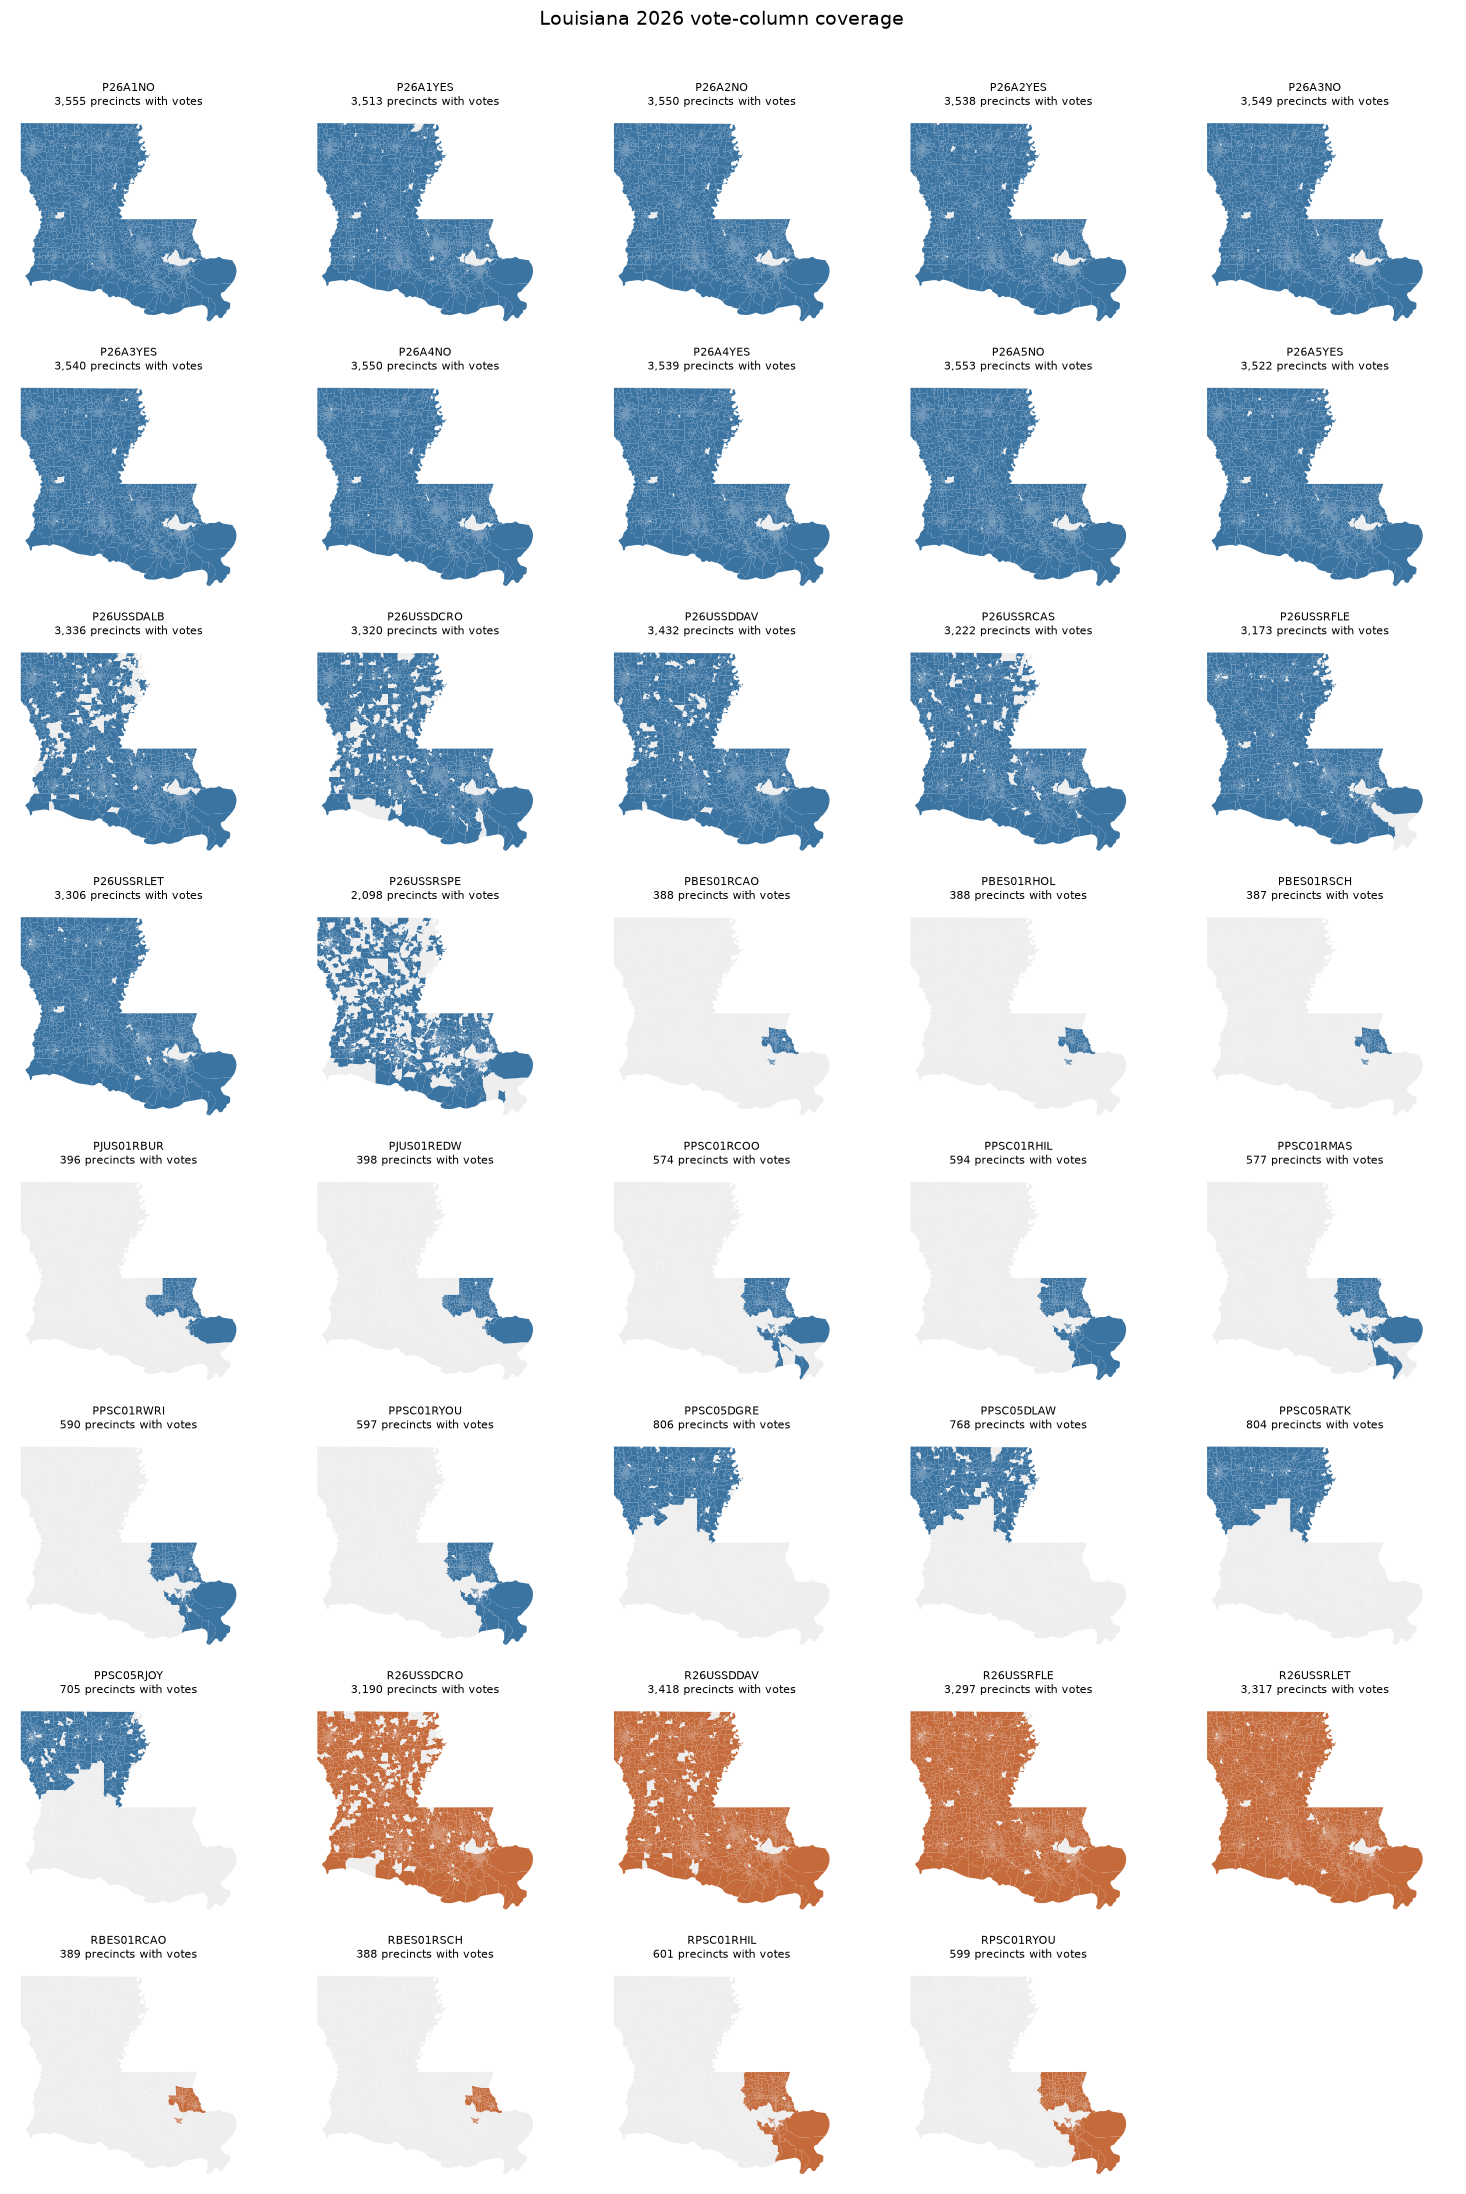

In [11]:
def plot_vote_columns(spatial: gpd.GeoDataFrame):
    """Show precincts with recorded votes for each of the 39 vote columns."""
    vote_columns = spatial.columns[5:-1]
    assert len(vote_columns) == 39

    figure, axes = plt.subplots(8, 5, figsize=(15, 22))
    for axis, column in zip(axes.flat, vote_columns):
        has_votes = spatial[column].gt(0)
        color = "#3b73a1" if column.startswith("P") else "#c46a3b"

        spatial.plot(
            ax=axis,
            color=has_votes.map({True: color, False: "#eeeeee"}),
            edgecolor="none",
        )
        axis.set_title(f"{column}\n{has_votes.sum():,} precincts with votes", fontsize=8)
        axis.set_axis_off()

    axes.flat[-1].set_axis_off()
    figure.suptitle("Louisiana 2026 vote-column coverage", fontsize=14, y=0.995)
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    return figure

# Plot one coverage map for each of the 39 vote columns.
plot_vote_columns(spatial)
plt.show()